In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import norm
from sklearn.ensemble import BaggingRegressor
from pyexpat import model
from itertools import combinations
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
from scipy.stats import qmc


print("All imports successful!")

All imports successful!


Sampling was already done in a separate notebook, this just makes it much more clean with all of the sampled datasets already setup in csvs.

In [12]:
df = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/chf_combined.csv")
df_lhs = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/lhs_samples.csv")
df_multi_stratified = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/multi_stratified_samples.csv")
df_random_samples = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/random_samples.csv")

#check that all datasets loaded properly
print("Combined dataset shape:", df.shape)
print("LHS samples shape:", df_lhs.shape)
print("Multi-stratified samples shape:", df_multi_stratified.shape)
print("Random samples shape:", df_random_samples.shape)
print("All datasets loaded successfully!")

Combined dataset shape: (2500, 7)
LHS samples shape: (1000, 7)
Multi-stratified samples shape: (1267, 7)
Random samples shape: (1000, 7)
All datasets loaded successfully!


In [13]:
#pick target
target = "CHF (kW m-2)"

features = [col for col in df.columns if col != target]

Sets up all of our train test variables for each separate sampling method.

In [14]:
#non sampled dataset
X = df[features]
y = df[target]

#80/20 train test split for non sampled data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_original = X.copy()
y_original = y.copy()

X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X_original, y_original, test_size=0.2, random_state=42)

X_lhs = df_lhs[features]
y_lhs = df_lhs[target]
#80/20 train test split for LHS samples
X_train_lhs, X_test_lhs, y_train_lhs, y_test_lhs = train_test_split(X_lhs, y_lhs, test_size=0.2, random_state=42)

X_multi_stratified = df_multi_stratified[features]
y_multi_stratified = df_multi_stratified[target]
#80/20 train test split for multi-stratified samples
X_train_multi_stratified, X_test_multi_stratified, y_train_multi_stratified, y_test_multi_stratified = train_test_split(X_multi_stratified, y_multi_stratified, test_size=0.2, random_state=42)

X_random = df_random_samples[features]
y_random = df_random_samples[target]
#80/20 train test split for random samples
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(X_random, y_random, test_size=0.2, random_state=42)

Builds 8 separate neural network architectures. Diversity is the main goal here, architectures include:
-Standard
-Narrow and deep
-Narrow and shallow
-Wide and deep
-Wide and shallow
-Massive hidden layer -> small -> massive -> small
-Counting down hidden layers, 16, 15, ..., 5, 4
-Counting up prime numbers, 3, 5, ..., 17
Then puts all of the models into a dictionary for easy iteration with k fold cv later.

In [15]:
#Preproccessing and Model Pipeline
from pyexpat import model


numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

#standared architecture
model_standard = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Narrow and Deep Model
model_narrow_deep = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        #we'll implement a narrow and deep architecture
        hidden_layer_sizes=(256, 128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Narrow and Shallow Model
model_narrow_shallow = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        #we'll implement a narrow and shallow architecture
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Wide and Deep Model
model_wide_deep = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(512, 256, 128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Wide and Shallow
model_wide_shallow = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Goofy Model #1
model_Goofy1 = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256, 2, 256, 3),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Goofy Model #2
model_Goofy2 = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(16, 15, 14, 13, 12, 11, 10, 9, 8, 7 ,6, 5, 4),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

model_Goofy3 = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(3, 5, 7, 11, 13, 17),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

models = {
    "Standard": model_standard,
    "Narrow_Deep": model_narrow_deep,
    "Narrow_Shallow": model_narrow_shallow,
    "Wide_Deep": model_wide_deep,
    "Wide_Shallow": model_wide_shallow,
    "Goofy1": model_Goofy1,
    "Goofy2": model_Goofy2,
    "Goofy3": model_Goofy3
}

datasets = {
    "Non_Sampled": (X_train, y_train),
    "LHS": (X_train_lhs, y_train_lhs),
    "Multi_Stratified": (X_train_multi_stratified, y_train_multi_stratified),
    "Random": (X_train_random, y_train_random)
}

for model_name, model in models.items():
    for dataset_name, (X_train, y_train) in datasets.items():
        print(f"Training {model_name} on {dataset_name} dataset...")
        model.fit(X_train, y_train)
        print(f"{model_name} trained on {dataset_name} dataset successfully!")


Training Standard on Non_Sampled dataset...


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Standard trained on Non_Sampled dataset successfully!
Training Standard on LHS dataset...


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Standard trained on LHS dataset successfully!
Training Standard on Multi_Stratified dataset...


...

d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Wide_Shallow trained on Random dataset successfully!
Training Goofy1 on Non_Sampled dataset...
Goofy1 trained on Non_Sampled dataset successfully!
Training Goofy1 on LHS dataset...
Goofy1 trained on LHS dataset successfully!
Training Goofy1 on Multi_Stratified dataset...
Goofy1 trained on Multi_Stratified dataset successfully!
Training Goofy1 on Random dataset...
Goofy1 trained on Random dataset successfully!
Training Goofy2 on Non_Sampled dataset...
Goofy2 trained on Non_Sampled dataset successfully!
Training Goofy2 on LHS dataset...


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Goofy2 trained on LHS dataset successfully!
Training Goofy2 on Multi_Stratified dataset...
Goofy2 trained on Multi_Stratified dataset successfully!
Training Goofy2 on Random dataset...
Goofy2 trained on Random dataset successfully!
Training Goofy3 on Non_Sampled dataset...
Goofy3 trained on Non_Sampled dataset successfully!
Training Goofy3 on LHS dataset...
Goofy3 trained on LHS dataset successfully!
Training Goofy3 on Multi_Stratified dataset...
Goofy3 trained on Multi_Stratified dataset successfully!
Training Goofy3 on Random dataset...
Goofy3 trained on Random dataset successfully!


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


K fold cross validation. Loops through all sampling strategies/architectures, calculates mean r2, std r2 and k fold scores for each fold. This gives us an idea of how each model performs on each sampling set, along with how each sampling set interacts with different architectures.

Loops through all architectures/sampling types to predict CHF values for each.

In [16]:
#predict for all fitted models across sampling strategies
predictions = {}
for model_name, model in models.items():
    for dataset_name, (X_train, y_train) in datasets.items():
        if dataset_name == "LHS":
            X_test_current = X_test_lhs
            y_test_current = y_test_lhs
        elif dataset_name == "Multi_Stratified":
            X_test_current = X_test_multi_stratified
            y_test_current = y_test_multi_stratified
        elif dataset_name == "Random":
            X_test_current = X_test_random
            y_test_current = y_test_random
        else:
            X_test_current = X_test
            y_test_current = y_test
        
        print(f"Predicting with {model_name} on {dataset_name} test set...")
        y_pred = model.predict(X_test_current)
        predictions[(model_name, dataset_name)] = (y_pred, y_test_current)
        print(f"Prediction with {model_name} on {dataset_name} test set successful!")


Predicting with Standard on Non_Sampled test set...
Prediction with Standard on Non_Sampled test set successful!
Predicting with Standard on LHS test set...
Prediction with Standard on LHS test set successful!
Predicting with Standard on Multi_Stratified test set...
Prediction with Standard on Multi_Stratified test set successful!
Predicting with Standard on Random test set...
Prediction with Standard on Random test set successful!
Predicting with Narrow_Deep on Non_Sampled test set...
Prediction with Narrow_Deep on Non_Sampled test set successful!
Predicting with Narrow_Deep on LHS test set...
Prediction with Narrow_Deep on LHS test set successful!
Predicting with Narrow_Deep on Multi_Stratified test set...
Prediction with Narrow_Deep on Multi_Stratified test set successful!
Predicting with Narrow_Deep on Random test set...
Prediction with Narrow_Deep on Random test set successful!
Predicting with Narrow_Shallow on Non_Sampled test set...
Prediction with Narrow_Shallow on Non_Sampled 

K fold cross validation. Loops through all sampling strategies/architectures, calculates mean r2, std r2 and k fold scores for each fold. This gives us an idea of how each model performs on each sampling set, along with how each sampling set interacts with different architectures.

In [17]:
from sklearn.model_selection import cross_val_score
import numpy as np

sampling_strategies = ['random', 'lhs', 'multi_stratified', 'original']
architectures = ['standard', 'wide_deep', 'narrow_deep', 'wide_shallow', 'narrow_shallow', 'Goofy1', 'Goofy2', 'Goofy3']
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

results_standard = {}
for strategy in sampling_strategies:
    X_data = globals()[f'X_{strategy}']
    y_data = globals()[f'y_{strategy}']
    for arch in architectures:
        model = globals()[f'model_{arch}']
        scores = cross_val_score(model, X_data, y_data, cv=kf, scoring='r2')
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        results_standard[(strategy, arch)] = {'mean_r2': mean_score, 'std_r2': std_score, 'fold_scores': scores}
        print(f"{strategy} + {arch}: Mean R² = {mean_score:.3f}, Std = {std_score:.3f}")

d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

random + standard: Mean R² = -0.044, Std = 0.035
random + wide_deep: Mean R² = -0.706, Std = 0.174


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

random + narrow_deep: Mean R² = -0.591, Std = 0.124


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

...

original + wide_shallow: Mean R² = 0.867, Std = 0.015


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

original + narrow_shallow: Mean R² = 0.805, Std = 0.020
original + Goofy1: Mean R² = 0.968, Std = 0.006
original + Goofy2: Mean R² = 0.964, Std = 0.010


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


original + Goofy3: Mean R² = 0.872, Std = 0.024


Prints all of the results from the k fold cv above.

In [18]:
print("\nCross-Validation Results (Standard Models):")
for (strategy, arch), metrics in results_standard.items():
    print(f"{strategy} + {arch}: Mean R² = {metrics['mean_r2']:.3f}, Std = {metrics['std_r2']:.3f}, Fold Scores = {metrics['fold_scores']}")

best_model = max(results_standard.items(), key=lambda x: x[1]['mean_r2'])

print("\nBest Model Based on Mean R²:")
print(f"{best_model[0]} -> Mean R²: {best_model[1]['mean_r2']:.4f}, Std: {best_model[1]['std_r2']:.4f}")


Cross-Validation Results (Standard Models):
random + standard: Mean R² = -0.044, Std = 0.035, Fold Scores = [ 0.01702399 -0.06702267 -0.02892398 -0.06459953 -0.07844016]
random + wide_deep: Mean R² = -0.706, Std = 0.174, Fold Scores = [-0.73385911 -0.65649176 -1.02636724 -0.5419811  -0.56883852]
random + narrow_deep: Mean R² = -0.591, Std = 0.124, Fold Scores = [-0.59138339 -0.81924462 -0.54146104 -0.4484582  -0.55360271]
random + wide_shallow: Mean R² = -0.078, Std = 0.064, Fold Scores = [ 0.00643377 -0.16600232 -0.02870457 -0.06928884 -0.13186954]
random + narrow_shallow: Mean R² = -1.433, Std = 0.240, Fold Scores = [-1.1976187  -1.75733088 -1.13680869 -1.43853478 -1.63452876]
random + Goofy1: Mean R² = -0.043, Std = 0.035, Fold Scores = [ 0.02037323 -0.06196338 -0.03210954 -0.06988282 -0.07367154]
random + Goofy2: Mean R² = -0.128, Std = 0.067, Fold Scores = [-0.17680095 -0.07363034 -0.08832319 -0.23574264 -0.06514493]
random + Goofy3: Mean R² = -0.017, Std = 0.015, Fold Scores = [

Prints the top 10 models in terms of k fold performance. Gives us a potential preliminary idea of bias through strong model performance.

In [19]:
sorted_results_standard = sorted(results_standard.items(), key=lambda x: x[1]['mean_r2'], reverse=True)

print("\nTop 10 Models (Standard):")
for (strategy, arch), metrics in sorted_results_standard[:10]:
    print(f"{strategy} + {arch}: Mean R² = {metrics['mean_r2']:.4f}, Std = {metrics['std_r2']:.4f}")

df_results_standard = pd.DataFrame([
    {
        "Strategy": strategy,
        "Architecture": arch,
        "Mean R2": metrics["mean_r2"],
        "Std": metrics["std_r2"]
    }
    for (strategy, arch), metrics in results_standard.items()
])

df_results_standard = df_results_standard.sort_values(by="Mean R2", ascending=False)

print(df_results_standard.head(10))


Top 10 Models (Standard):
original + wide_deep: Mean R² = 0.9708, Std = 0.0099
original + narrow_deep: Mean R² = 0.9689, Std = 0.0102
original + Goofy1: Mean R² = 0.9679, Std = 0.0060
original + Goofy2: Mean R² = 0.9644, Std = 0.0103
multi_stratified + narrow_deep: Mean R² = 0.9627, Std = 0.0053
multi_stratified + wide_deep: Mean R² = 0.9623, Std = 0.0063
multi_stratified + Goofy2: Mean R² = 0.9491, Std = 0.0117
original + standard: Mean R² = 0.9459, Std = 0.0052
multi_stratified + Goofy1: Mean R² = 0.9450, Std = 0.0083
original + Goofy3: Mean R² = 0.8719, Std = 0.0241
            Strategy Architecture   Mean R2       Std
25          original    wide_deep  0.970806  0.009939
26          original  narrow_deep  0.968869  0.010217
29          original       Goofy1  0.967945  0.006020
30          original       Goofy2  0.964384  0.010308
18  multi_stratified  narrow_deep  0.962673  0.005264
17  multi_stratified    wide_deep  0.962268  0.006344
22  multi_stratified       Goofy2  0.949055  

Plot the K fold results vs r2 scores. This gives us a visualization of model bias through k fold cv.

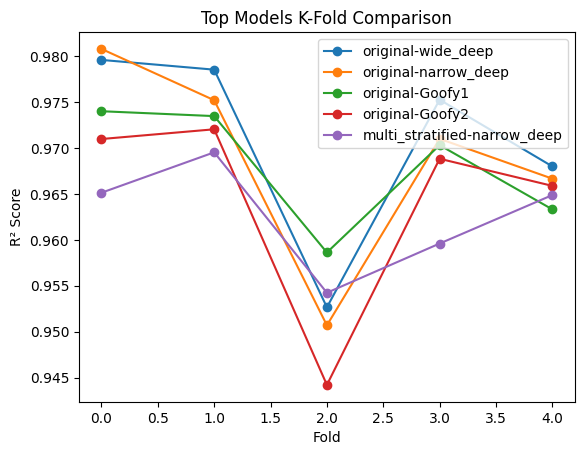

In [20]:
top_models = sorted_results_standard[:5]

for (strategy, arch), metrics in top_models:
    plt.plot(metrics["fold_scores"], marker='o', label=f"{strategy}-{arch}")

plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("Top Models K-Fold Comparison")
plt.legend()
plt.show()

Same model implementations as above, just all of them are bootstrapped. While model performance is not the most important thing to look at with bias, having better performing vs worse performing models gives us more data to work with where we need it.

In [21]:
#Preproccessing and Model Pipeline
numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)
#Basic Model
model_standard_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Wide and Deep Model
model_wide_deep_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(512, 256, 128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Narrow and Deep (bootstrap) - mirror of non-boot narrow_deep
model_narrow_deep_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Wide and Shallow (bootstrap) - mirror of non-boot wide_shallow
model_wide_shallow_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Narrow and Shallow
model_narrow_shallow_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Wide and Deep Boot Model
model_wide_deep_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Narrow and Shallow
model_narrow_shallow_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Boot strapped Goofy Model #1
model_Goofy1_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256, 2, 256, 3),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Boot Strapped Goofy Model #2
model_Goofy2_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(16, 15, 14, 13, 12, 11, 10, 9, 8, 7 ,6, 5, 4),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#One More Goofy Model
model_Goofy3_bootstrap = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(3, 5, 7, 11, 13, 17),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

bootstrapped_models = {}
#add all bootstrapped models to the dictionary
bootstrapped_models["Boot"] = model_standard_bootstrap
bootstrapped_models["Boot_Goofy1"] = model_Goofy1_bootstrap
bootstrapped_models["Boot_Goofy2"] = model_Goofy2_bootstrap
bootstrapped_models["Boot_Goofy3"] = model_Goofy3_bootstrap
bootstrapped_models["Wide_Deep_Boot"] = model_wide_deep_bootstrap
bootstrapped_models["Wide_Shallow_Boot"] = model_wide_shallow_bootstrap
bootstrapped_models["Narrow_Deep_Boot"] = model_narrow_deep_bootstrap
bootstrapped_models["Narrow_Shallow_Boot"] = model_narrow_shallow_bootstrap

#Train Basic Model
model_standard_bootstrap.fit(X_train, y_train)
model_standard_bootstrap.fit(X_train_lhs, y_train_lhs)
model_standard_bootstrap.fit(X_train_multi_stratified, y_train_multi_stratified)

#Train Wide Model
model_wide_deep_bootstrap.fit(X_train, y_train)
model_wide_deep_bootstrap.fit(X_train_lhs, y_train_lhs)
model_wide_deep_bootstrap.fit(X_train_multi_stratified, y_train_multi_stratified)
#Train Shallow Model
model_narrow_shallow_bootstrap.fit(X_train, y_train)
model_narrow_shallow_bootstrap.fit(X_train_lhs, y_train_lhs)
model_narrow_shallow_bootstrap.fit(X_train_multi_stratified, y_train_multi_stratified)

for model_name, model in bootstrapped_models.items():
    for dataset_name, (X_train, y_train) in datasets.items():
        print(f"Training {model_name} on {dataset_name} dataset...")
        model.fit(X_train, y_train)
        print(f"{model_name} trained on {dataset_name} dataset successfully!")


models = {
    "Standard": model,
    "Wide_Deep_Boot": model_wide_deep_bootstrap,
    "Wide_Shallow_Boot": model_wide_shallow_bootstrap,
    "Narrow_Deep_Boot": model_narrow_deep_bootstrap,
    "Narrow_Shallow_Boot": model_narrow_shallow_bootstrap,
    "Boot": model_standard_bootstrap,
    "Boot_Goofy1": model_Goofy1_bootstrap,
    "Boot_Goofy2": model_Goofy2_bootstrap,
    "Boot_Goofy3": model_Goofy3_bootstrap
}

print("All Models Trained!")



d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

Training Boot on Non_Sampled dataset...


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Boot trained on Non_Sampled dataset successfully!
Training Boot on LHS dataset...


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


...

d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Narrow_Shallow_Boot trained on LHS dataset successfully!
Training Narrow_Shallow_Boot on Multi_Stratified dataset...


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Narrow_Shallow_Boot trained on Multi_Stratified dataset successfully!
Training Narrow_Shallow_Boot on Random dataset...
Narrow_Shallow_Boot trained on Random dataset successfully!
All Models Trained!


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Same prediction code as above.

In [22]:
#predict for all fitted models across sampling strategies
predictions_bootstrapped = {}
for model_name, model in models.items():
    for dataset_name, (X_train, y_train) in datasets.items():
        if dataset_name == "LHS":
            X_test_current = X_test_lhs
            y_test_current = y_test_lhs
        elif dataset_name == "Multi_Stratified":
            X_test_current = X_test_multi_stratified
            y_test_current = y_test_multi_stratified
        elif dataset_name == "Random":
            X_test_current = X_test_random
            y_test_current = y_test_random
        else:
            X_test_current = X_test
            y_test_current = y_test
        
        print(f"Predicting with {model_name} on {dataset_name} test set...")
        y_pred = model.predict(X_test_current)
        predictions_bootstrapped[(model_name, dataset_name)] = (y_pred, y_test_current)
        print(f"Prediction with {model_name} on {dataset_name} test set successful!")

Predicting with Standard on Non_Sampled test set...
Prediction with Standard on Non_Sampled test set successful!
Predicting with Standard on LHS test set...
Prediction with Standard on LHS test set successful!
Predicting with Standard on Multi_Stratified test set...
Prediction with Standard on Multi_Stratified test set successful!
Predicting with Standard on Random test set...
Prediction with Standard on Random test set successful!
Predicting with Wide_Deep_Boot on Non_Sampled test set...
Prediction with Wide_Deep_Boot on Non_Sampled test set successful!
Predicting with Wide_Deep_Boot on LHS test set...
Prediction with Wide_Deep_Boot on LHS test set successful!
Predicting with Wide_Deep_Boot on Multi_Stratified test set...
Prediction with Wide_Deep_Boot on Multi_Stratified test set successful!
Predicting with Wide_Deep_Boot on Random test set...
Prediction with Wide_Deep_Boot on Random test set successful!
Predicting with Wide_Shallow_Boot on Non_Sampled test set...
Prediction with Wid

Same k fold cv implementation as above, this time for bootstrapped models.

In [23]:
sampling_strategies = ['random', 'lhs', 'multi_stratified', 'original']
architectures = ['standard_bootstrap', 'wide_deep_bootstrap', 'narrow_deep_bootstrap', 'wide_shallow_bootstrap', 'narrow_shallow_bootstrap', 'Goofy1_bootstrap', 'Goofy2_bootstrap', 'Goofy3_bootstrap']
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

results_bootstrap = {}
# Build a robust mapping from architecture names to model objects to avoid KeyError from globals()
model_lookup = {}
for arch in architectures:
    # primary name: model_<arch>
    primary = f'model_{arch}'
    if primary in globals():
        model_lookup[arch] = globals()[primary]
        continue
    # try variants (strip suffixes)
    alt = arch.replace('_bootstrap', '').replace('bootstrap', '').rstrip('_')
    tried = []
    for candidate in [f'model_{alt}', f'model_{alt}_boot', f'model_{alt}_bootstrap']:
        tried.append(candidate)
        if candidate in globals():
            model_lookup[arch] = globals()[candidate]
            break

for strategy in sampling_strategies:
    X_data = globals()[f'X_{strategy}']
    y_data = globals()[f'y_{strategy}']
    for arch in architectures:
        model = model_lookup[arch]
        scores = cross_val_score(model, X_data, y_data, cv=kf, scoring='r2')
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        results_bootstrap[(strategy, arch)] = {'mean_r2': mean_score, 'std_r2': std_score, 'fold_scores': scores}
        print(f"{strategy} + {arch}: Mean R² = {mean_score:.3f}, Std = {std_score:.3f}")

d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

random + standard_bootstrap: Mean R² = -0.044, Std = 0.035


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

random + wide_deep_bootstrap: Mean R² = -0.591, Std = 0.124


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

...

original + wide_shallow_bootstrap: Mean R² = 0.867, Std = 0.015


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

original + narrow_shallow_bootstrap: Mean R² = 0.732, Std = 0.039
original + Goofy1_bootstrap: Mean R² = 0.968, Std = 0.006
original + Goofy2_bootstrap: Mean R² = 0.964, Std = 0.010


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


original + Goofy3_bootstrap: Mean R² = 0.872, Std = 0.024


Data bias visualization:
Plotting the distribution of the CHF dataset, density of the dataset, along with a normal distribution. This allows us to directly compare our distribution with a normal distribution to determine exactly where the data bias comes from.

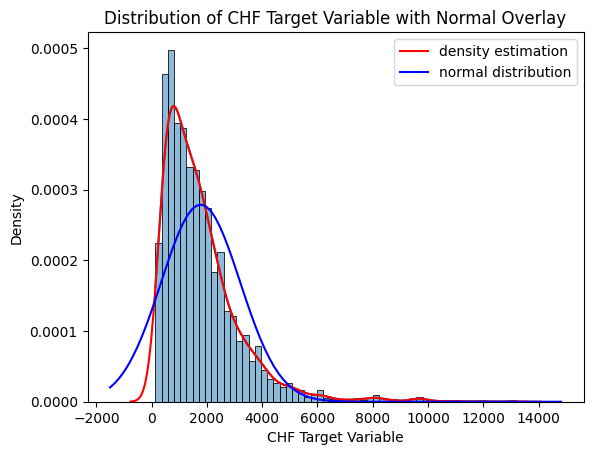

In [24]:
#density plot of chf variable with normal distribution overlayed
sns.histplot(df[target], kde=True, stat="density")
sns.kdeplot(df[target], color="red", label="density estimation")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, df[target].mean(), df[target].std())
plt.plot(x, p, color="blue", label="normal distribution")
plt.title("Distribution of CHF Target Variable with Normal Overlay")
plt.xlabel("CHF Target Variable")
plt.ylabel("Density")
plt.legend()
plt.show()

The chf dataset is clearly not normally distributed. This means that to aggregate the confidence interval we will have to accomodate for the skewed distribution.

Calculate confidence intervals for all models across all sampling types. 

In [25]:
def compute_pointwise_ci(preds, ci=0.95, method='percentile', n_boot=1000, random_state=None):
    rng = np.random.default_rng(random_state)
    preds = np.asarray(preds)
    if preds.ndim == 1:
        preds = preds[:, None]
    n_draws, n_samples = preds.shape
    alpha = 1 - ci
    mean = preds.mean(axis=0)
    if method == 'percentile':
        lo = np.percentile(preds, 100 * (alpha / 2), axis=0)
        hi = np.percentile(preds, 100 * (1 - alpha / 2), axis=0)
        return mean, lo, hi

def stack_preds_for_dataset(predictions, dataset_name):
    """Return stacked preds (n_draws, n_samples) and reference y_test.
    Raises a helpful error if nothing matches."""
    preds = []
    y_test_ref = None
    available = set()
    for (model_name, dname), (y_pred, y_test) in predictions.items():
        available.add(dname)
        if dname == dataset_name or dname.lower() == str(dataset_name).lower():
            preds.append(np.asarray(y_pred))
            if y_test_ref is None:
                y_test_ref = np.asarray(y_test)
    preds = np.vstack(preds)
    return preds, y_test_ref

Print all median confidence interval widths.

In [26]:
ci_results_individual = {}
for (model_name, dataset_name), (y_pred, y_test) in predictions.items():
    mean, lo, hi = compute_pointwise_ci(y_pred, method='percentile')
    ci_results_individual[(model_name, dataset_name)] = {
        'mean': mean,
        'lo': lo,
        'hi': hi,
        'y_test': y_test
    }
    widths = hi - lo
    print(f'{model_name} + {dataset_name}: Median CI width = {np.median(widths):.4f}')

Standard + Non_Sampled: Median CI width = 2522.1774
Standard + LHS: Median CI width = 2552.4742
Standard + Multi_Stratified: Median CI width = 2206.9612
Standard + Random: Median CI width = 3035.7021
Narrow_Deep + Non_Sampled: Median CI width = 8429.7354
Narrow_Deep + LHS: Median CI width = 10606.5969
Narrow_Deep + Multi_Stratified: Median CI width = 7725.0652
Narrow_Deep + Random: Median CI width = 8444.0411
Narrow_Shallow + Non_Sampled: Median CI width = 1278.9226
Narrow_Shallow + LHS: Median CI width = 1204.3509
Narrow_Shallow + Multi_Stratified: Median CI width = 1041.0349
Narrow_Shallow + Random: Median CI width = 1224.3178
Wide_Deep + Non_Sampled: Median CI width = 8398.7716
Wide_Deep + LHS: Median CI width = 10270.1672
Wide_Deep + Multi_Stratified: Median CI width = 8515.1685
Wide_Deep + Random: Median CI width = 9231.8446
Wide_Shallow + Non_Sampled: Median CI width = 2805.7280
Wide_Shallow + LHS: Median CI width = 2654.5001
Wide_Shallow + Multi_Stratified: Median CI width = 245

-Put all confidence interval results into a table 
-Run ttests on confidence interval widths between all sampling strategies.

In [27]:
#aggregate sampling bias with confidence intervals for all models and sampling strategies
aggregate_results = {}
for dataset_name in ['Non_Sampled', 'LHS', 'Multi_Stratified', 'Random']:
    all_preds, y_test_ref = stack_preds_for_dataset(predictions, dataset_name)
    mean, lo, hi = compute_pointwise_ci(all_preds, method='percentile')
    aggregate_results[dataset_name] = {
        'mean': mean,
        'lo': lo,
        'hi': hi,
        'y_test': y_test_ref
    }
    widths = hi - lo
    print(f'{dataset_name}: Median CI width = {np.median(widths):.4f}')

#paired ttests on ci widths across sampling strategies
#build median_widths_df from ci_results_individual dict
models = sorted({k[0] for k in ci_results_individual.keys()})
strategies = sorted({k[1] for k in ci_results_individual.keys()})

median_widths_df = pd.DataFrame(index=models, columns=strategies, dtype=float)
for m in models:
    for s in strategies:
        entry = ci_results_individual.get((m, s))
        if entry is None:
            median_widths_df.loc[m, s] = np.nan
        else:
            widths = np.asarray(entry['hi']) - np.asarray(entry['lo'])
            median_widths_df.loc[m, s] = np.nanmedian(widths)

print("\nMedian CI widths by model and sampling strategy:")
display(median_widths_df)

alpha = 0.05

#pairwise ttests
p_matrix = pd.DataFrame(np.nan, index=strategies, columns=strategies, dtype=float)
rows = []
for a, b in combinations(strategies, 2):
    x = median_widths_df[a].values
    y = median_widths_df[b].values
    mask = np.isfinite(x) & np.isfinite(y)
    n_pairs = int(np.sum(mask))
    if n_pairs < 2:
        stat = np.nan
        p = np.nan
    else:
        stat, p = ttest_rel(x[mask], y[mask])
    p_matrix.loc[a, b] = p
    p_matrix.loc[b, a] = p
    rows.append({'strategy_a': a, 'strategy_b': b, 't_stat': stat, 'p_value': p, 'n_pairs': n_pairs,
                 'mean_diff': np.nanmean(x[mask] - y[mask]) if n_pairs>0 else np.nan})

p_df = pd.DataFrame(rows)

reject, p_adj, _, _ = multipletests(p_df['p_value'].values, method='fdr_bh')
method_used = 'fdr_bh'

p_df['p_adj'] = p_adj
p_df['reject_null'] = reject

Non_Sampled: Median CI width = 5014.3047
LHS: Median CI width = 4838.4491
Multi_Stratified: Median CI width = 4856.9928
Random: Median CI width = 4968.3986

Median CI widths by model and sampling strategy:


,LHS,Multi_Stratified,Non_Sampled,Random
Goofy1,2610.534666,2017.865156,2324.920484,2858.630771
Goofy2,2887.702374,2490.690358,2506.021597,3151.589711
Goofy3,1677.171718,723.104536,740.877301,2093.162271
Narrow_Deep,10606.596860,7725.065200,8429.735386,8444.041147
Narrow_Shallow,1204.350865,1041.034944,1278.922648,1224.317847
Standard,2552.474162,2206.961220,2522.177402,3035.702130
Wide_Deep,10270.167180,8515.168502,8398.771569,9231.844587
Wide_Shallow,2654.500082,2456.908914,2805.727989,2464.637003


Visualize all findings from above with heatmaps, a boxplot, and a bar graph.

C:\Users\fonte\AppData\Local\Temp\ipykernel_12148\2382074664.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(width_arrays, labels=strategy_names, patch_artist=True)


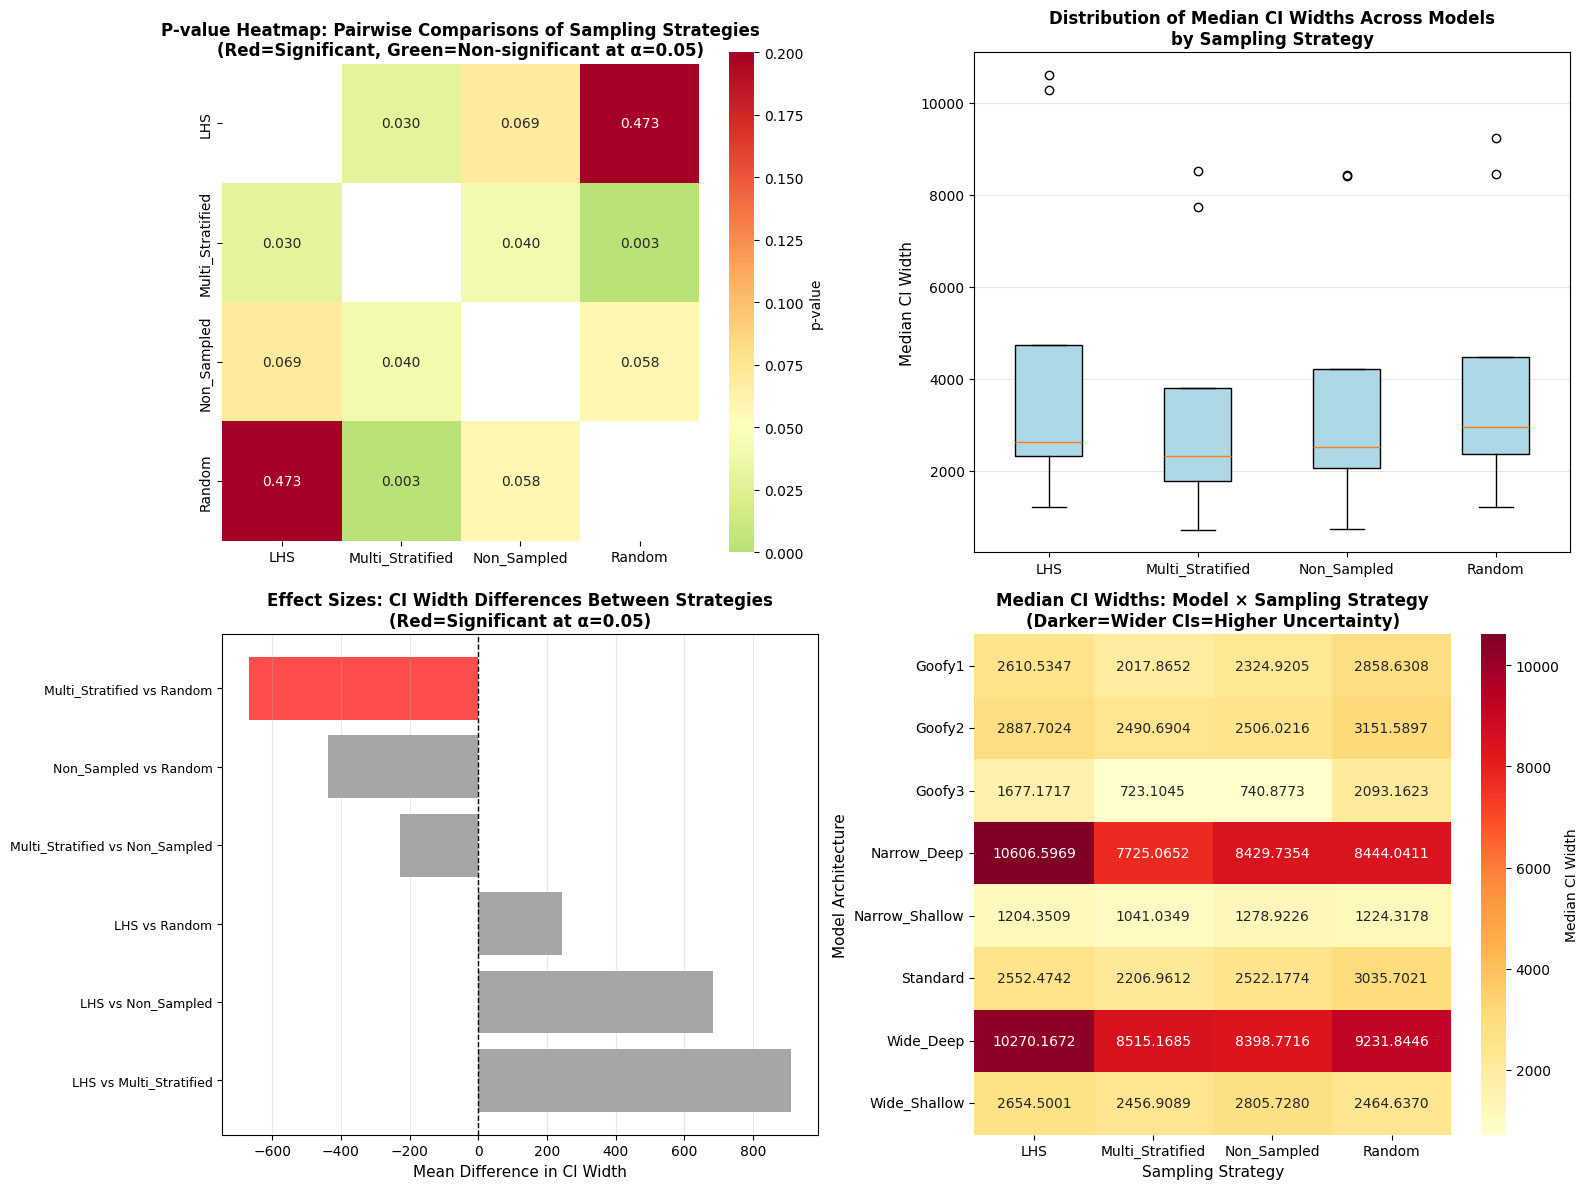

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#heatmap of p values with significance threshold
ax = axes[0, 0]
p_matrix_numeric = p_matrix.astype(float)
sns.heatmap(p_matrix_numeric, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0.05, 
            vmin=0, vmax=0.2, cbar_kws={'label': 'p-value'}, ax=ax, square=True)
ax.set_title('P-value Heatmap: Pairwise Comparisons of Sampling Strategies\n(Red=Significant, Green=Non-significant at α=0.05)', fontsize=12, fontweight='bold')

#distribution of median ci widths by sampling strategy
ax = axes[0, 1]
ci_width_data = []
for strategy in strategies:
    widths = median_widths_df[strategy].dropna().values
    ci_width_data.append({'Strategy': strategy, 'Width': widths})

strategy_names = [d['Strategy'] for d in ci_width_data]
width_arrays = [d['Width'] for d in ci_width_data]
bp = ax.boxplot(width_arrays, labels=strategy_names, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Median CI Width', fontsize=11)
ax.set_title('Distribution of Median CI Widths Across Models\nby Sampling Strategy', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

#effect sizes (mean differences) from ttests
ax = axes[1, 0]
p_df_sorted = p_df.sort_values('mean_diff', ascending=False)
colors = ['red' if x < 0.05 else 'gray' for x in p_df_sorted['p_adj']]
bars = ax.barh(range(len(p_df_sorted)), p_df_sorted['mean_diff'], color=colors, alpha=0.7)
ax.set_yticks(range(len(p_df_sorted)))
ax.set_yticklabels([f"{row['strategy_a']} vs {row['strategy_b']}" 
                      for _, row in p_df_sorted.iterrows()], fontsize=9)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Mean Difference in CI Width', fontsize=11)
ax.set_title('Effect Sizes: CI Width Differences Between Strategies\n(Red=Significant at α=0.05)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

#heatmap of median ci widths (model x strategy)
ax = axes[1, 1]
sns.heatmap(median_widths_df, annot=True, fmt='.4f', cmap='YlOrRd', 
            cbar_kws={'label': 'Median CI Width'}, ax=ax)
ax.set_title('Median CI Widths: Model × Sampling Strategy\n(Darker=Wider CIs=Higher Uncertainty)', fontsize=12, fontweight='bold')
ax.set_ylabel('Model Architecture', fontsize=11)
ax.set_xlabel('Sampling Strategy', fontsize=11)

plt.tight_layout()
plt.show()


Plot densities of all sampled data in order to explore sampling bias.

Numeric columns used for bias comparison:
['D (m)', 'L (m)', 'P (kPa)', 'G (kg m-2s-1)', 'Tin (C)', 'Xe (-)', 'CHF (kW m-2)']

LHS Bias Summary:
                 Full Mean      LHS Mean  Mean Bias %     Full Std  \
D (m)             0.008879      0.009206     3.683787     0.002235   
L (m)             2.612748      7.936256   203.751305     1.850711   
P (kPa)        9965.752860  10542.724195     5.789541  5342.566521   
G (kg m-2s-1)  1982.624360   3954.344992    99.450036  1426.385745   
Tin (C)         198.157117    193.936355    -2.130008    85.865419   
Xe (-)            0.350011      0.317652    -9.245179     0.261405   
CHF (kW m-2)   1771.948356   6653.051883   275.465338  1430.494750   

                   LHS Std  Std Bias %  
D (m)             0.004024   80.039499  
L (m)             4.463917  141.200146  
P (kPa)        6033.265694   12.928228  
G (kg m-2s-1)  2268.617582   59.046569  
Tin (C)         105.788343   23.202500  
Xe (-)            0.417060   59.545491  
CHF (kW

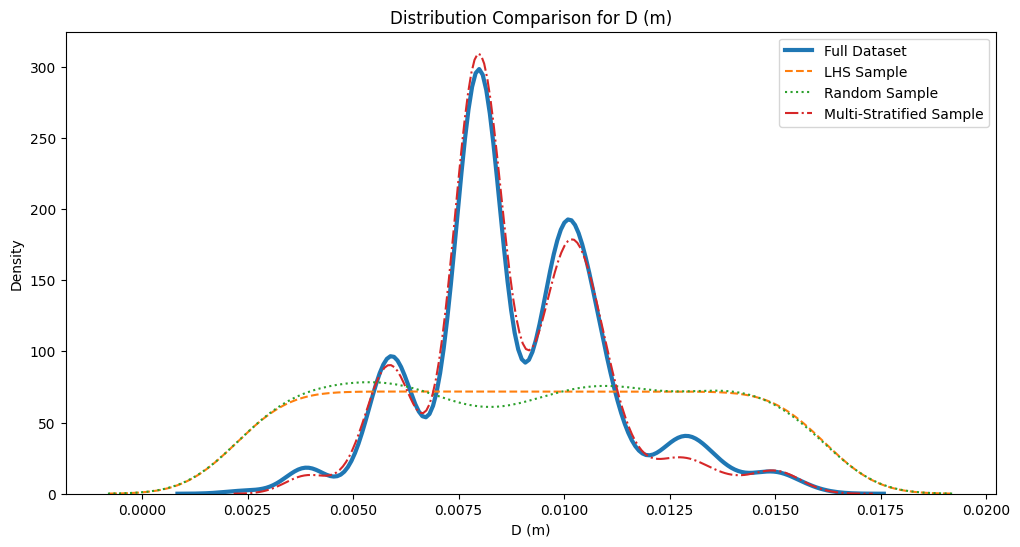

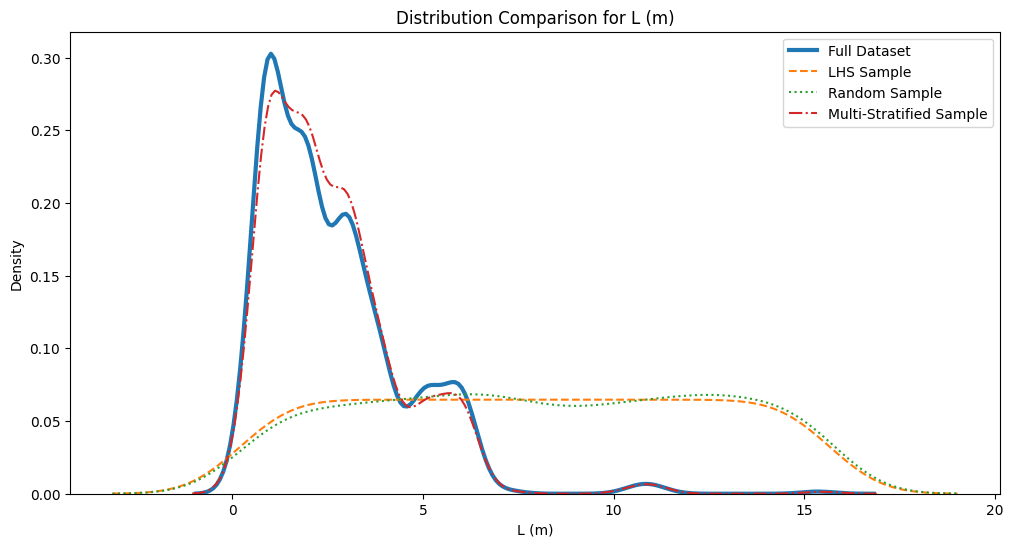

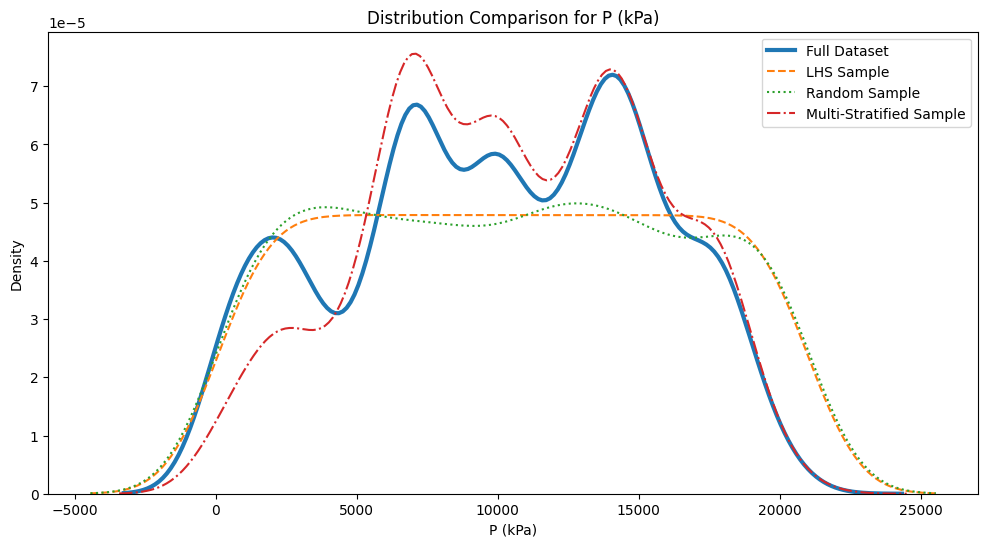

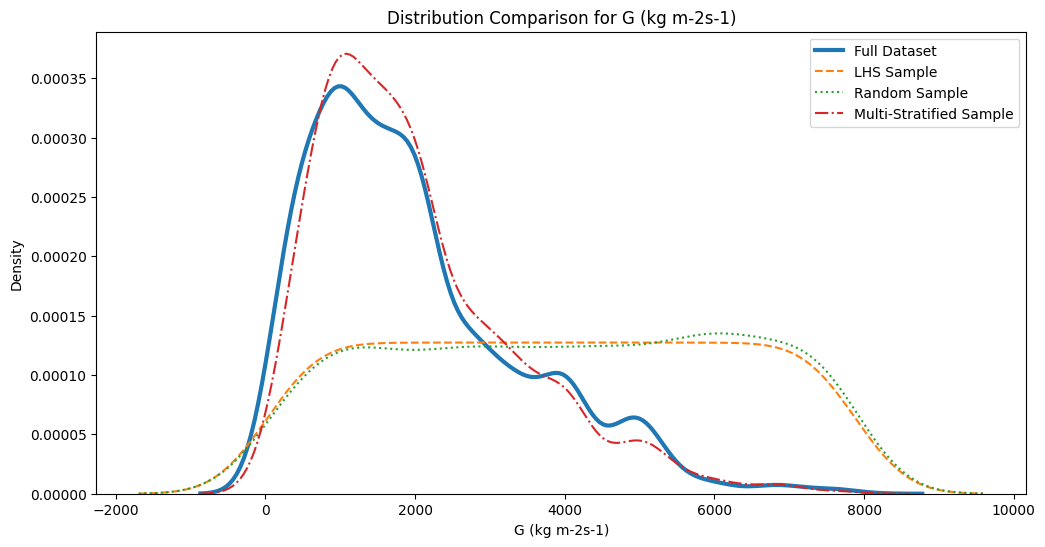

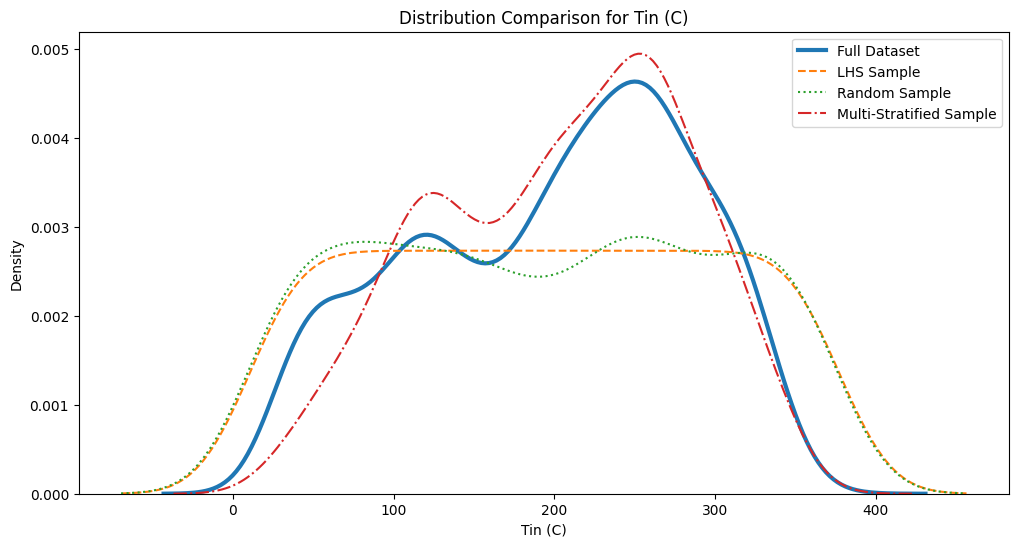

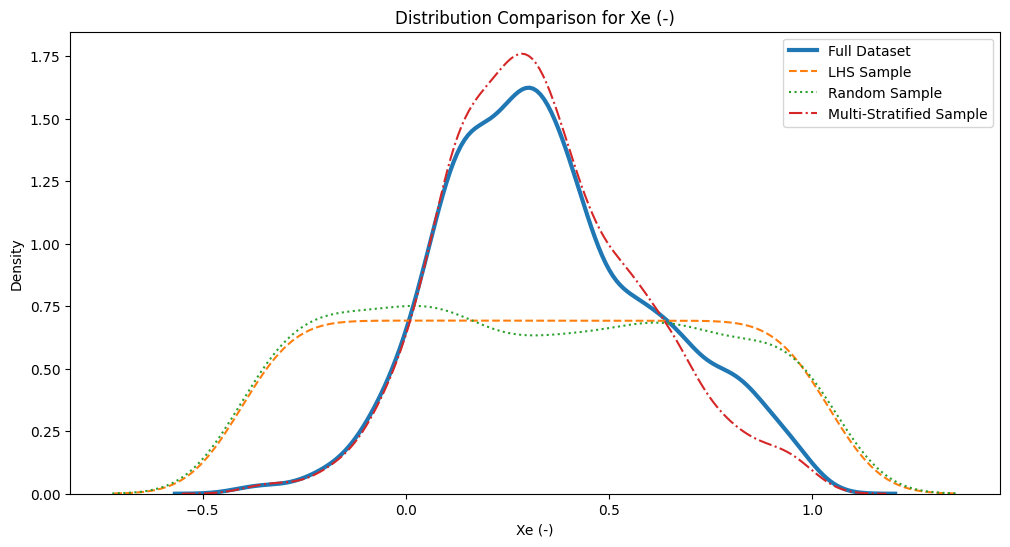

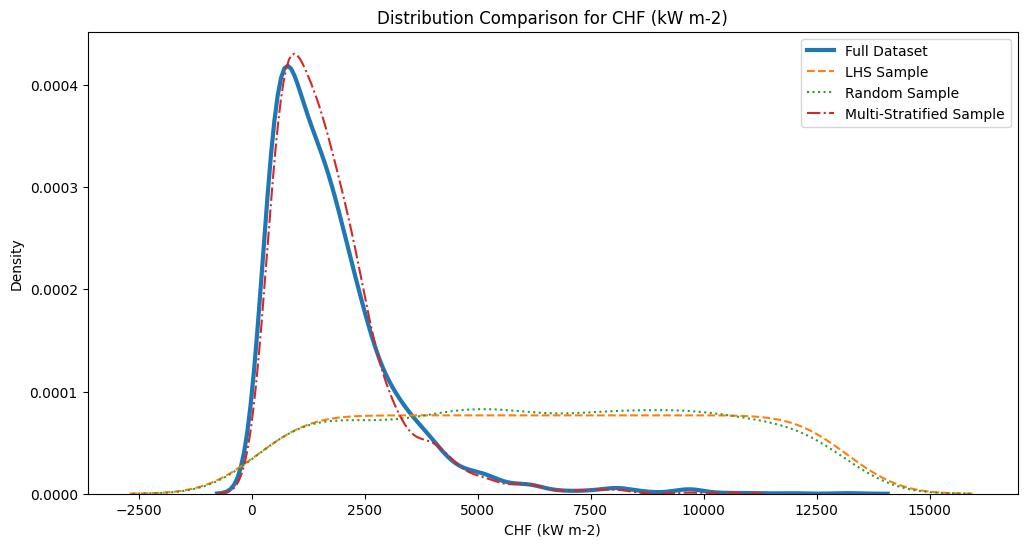

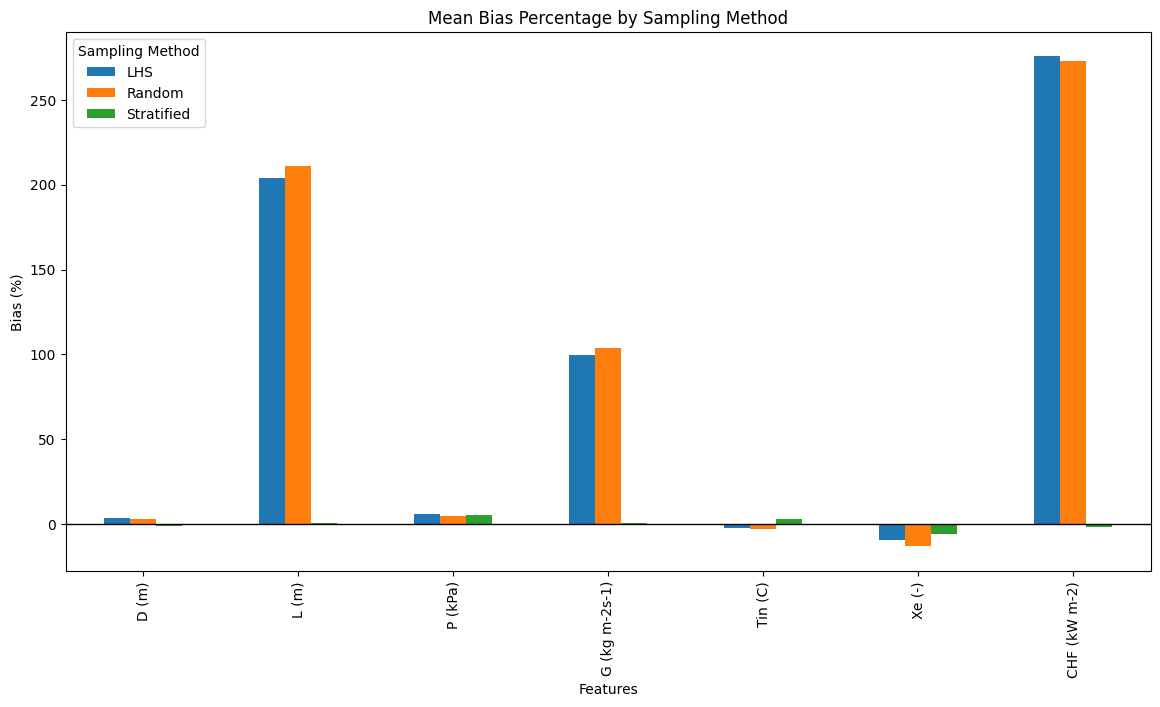

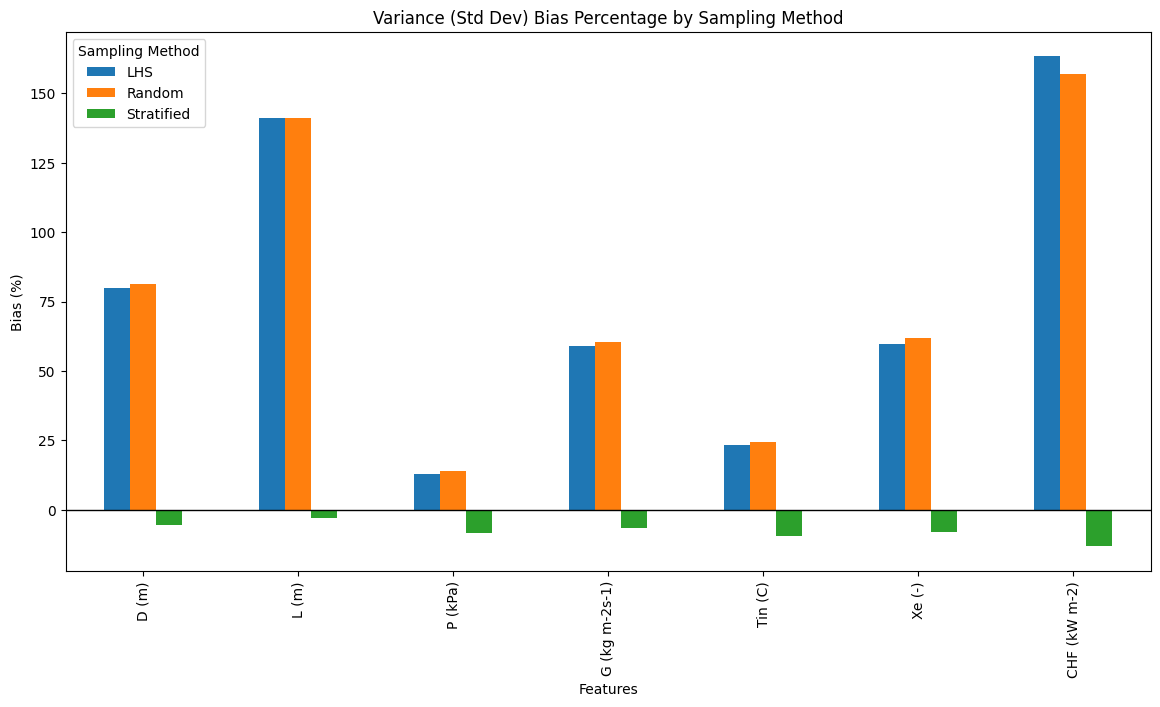

In [29]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns used for bias comparison:")
print(numeric_cols)

#Summary Comparison
def compare_summary_stats(full_df, sample_df, sample_name):
    comparison = pd.DataFrame({
        "Full Mean": full_df[numeric_cols].mean(),
        f"{sample_name} Mean": sample_df[numeric_cols].mean(),
        "Mean Bias %": ((sample_df[numeric_cols].mean() - full_df[numeric_cols].mean()) / full_df[numeric_cols].mean()) * 100,
        
        "Full Std": full_df[numeric_cols].std(),
        f"{sample_name} Std": sample_df[numeric_cols].std(),
        "Std Bias %": ((sample_df[numeric_cols].std() - full_df[numeric_cols].std()) / full_df[numeric_cols].std()) * 100
    })
    return comparison

lhs_stats = compare_summary_stats(df, df_lhs, "LHS")
random_stats = compare_summary_stats(df, df_random_samples, "Random")
strat_stats = compare_summary_stats(df, df_multi_stratified, "Stratified")

print("\nLHS Bias Summary:")
print(lhs_stats)

print("\nRandom Bias Summary:")
print(random_stats)

print("\nStratified Bias Summary:")
print(strat_stats)

# distribution Graphs
for col in numeric_cols:
    plt.figure(figsize=(12,6))
    
    sns.kdeplot(df[col], label="Full Dataset", linewidth=3)
    sns.kdeplot(df_lhs[col], label="LHS Sample", linestyle="--")
    sns.kdeplot(df_random_samples[col], label="Random Sample", linestyle=":")
    sns.kdeplot(df_multi_stratified[col], label="Multi-Stratified Sample", linestyle="-.")
    
    plt.title(f"Distribution Comparison for {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

#mean Bias
bias_df = pd.DataFrame({
    "LHS": lhs_stats["Mean Bias %"],
    "Random": random_stats["Mean Bias %"],
    "Stratified": strat_stats["Mean Bias %"]
})

bias_df.plot(kind="bar", figsize=(14,7))
plt.axhline(0, color='black', linewidth=1)
plt.title("Mean Bias Percentage by Sampling Method")
plt.ylabel("Bias (%)")
plt.xlabel("Features")
plt.legend(title="Sampling Method")
plt.show()

#variance Bias
var_bias_df = pd.DataFrame({
    "LHS": lhs_stats["Std Bias %"],
    "Random": random_stats["Std Bias %"],
    "Stratified": strat_stats["Std Bias %"]
})

var_bias_df.plot(kind="bar", figsize=(14,7))
plt.axhline(0, color='black', linewidth=1)
plt.title("Variance (Std Dev) Bias Percentage by Sampling Method")
plt.ylabel("Bias (%)")
plt.xlabel("Features")
plt.legend(title="Sampling Method")
plt.show()